Graph generated with 40 nodes and 356 edges
Block IDs shape: torch.Size([40])
Unique block IDs: tensor([0, 1])


/tmp/ipykernel_1501291/3369160836.py:71: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10')


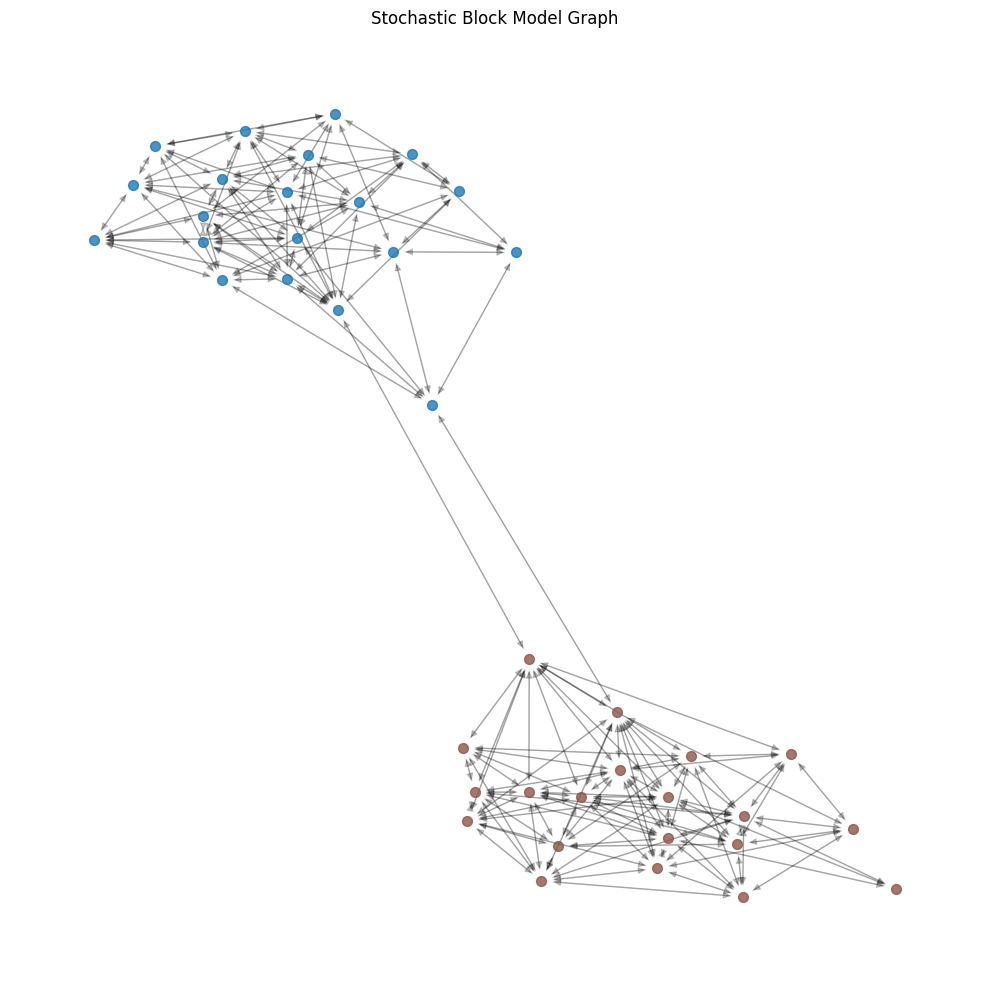

Epoch 10/100, Loss: 0.6477
Epoch 20/100, Loss: 0.5995
Epoch 30/100, Loss: 0.5611
Epoch 40/100, Loss: 0.5252
Epoch 50/100, Loss: 0.4871
Epoch 60/100, Loss: 0.4468
Epoch 70/100, Loss: 0.4069
Epoch 80/100, Loss: 0.3670
Epoch 90/100, Loss: 0.3275
Epoch 100/100, Loss: 0.2896


In [6]:
import torch
import torch_geometric
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from torch_geometric.utils import to_networkx
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def generate_stochastic_block_model(n_blocks, block_size, p_within, p_between):
    n = n_blocks * block_size
    edge_index = []
    
    for i in range(n):
        for j in range(i+1, n):
            if i // block_size == j // block_size:
                if np.random.random() < p_within:
                    edge_index.append([i, j])
                    edge_index.append([j, i])
            else:
                if np.random.random() < p_between:
                    edge_index.append([i, j])
                    edge_index.append([j, i])
    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    # Generate node features (random for this example)
    x = torch.randn(n, 10)  # 10-dimensional node features
    
    # Generate node labels (binary classification for this example)
    y = torch.randint(0, 2, (n,))
    
    # Generate block identifiers
    block_ids = torch.tensor([i // block_size for i in range(n)], dtype=torch.long)
    
    return Data(x=x, edge_index=edge_index, y=y, block_id=block_ids)

class GNN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GNN, self).__init__()
        self.conv = GCNConv(in_channels, hidden_channels)
        self.linear = torch.nn.Linear(hidden_channels, out_channels)
    
    def forward(self, x, edge_index):
        x = self.conv(x, edge_index)
        x = torch.relu(x)
        x = self.linear(x)
        return x

def train_gnn(model, data, optimizer, criterion, num_epochs):
    model.train()
    for epoch in range(num_epochs):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out.squeeze(), data.y.float())
        loss.backward()
        optimizer.step()
        
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}')

def visualize_graph(data):
    G = to_networkx(data)
    plt.figure(figsize=(10, 10))
    
    # Get node positions using spring layout
    pos = nx.spring_layout(G)
    
    # Create a color map
    num_blocks = data.block_id.max().item() + 1
    color_map = plt.cm.get_cmap('tab10')
    
    # Draw nodes
    for i in range(num_blocks):
        nx.draw_networkx_nodes(G, pos, 
                               nodelist=[node for node in G.nodes() if data.block_id[node].item() == i],
                               node_color=[color_map(i / num_blocks)],
                               node_size=50,
                               alpha=0.8)
    
    # Draw edges
    nx.draw_networkx_edges(G, pos, alpha=0.2)
    
    plt.title("Stochastic Block Model Graph")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

# def main():
# Generate stochastic block model graph
n_blocks = 2
block_size = 20
p_within = 0.5
p_between = 0.005
data = generate_stochastic_block_model(n_blocks, block_size, p_within, p_between)

print(f"Graph generated with {data.num_nodes} nodes and {data.num_edges} edges")
print(f"Block IDs shape: {data.block_id.shape}")
print(f"Unique block IDs: {data.block_id.unique()}")

# Visualize the graph
visualize_graph(data)

# Initialize GNN
in_channels = data.num_node_features
hidden_channels = 16
out_channels = 1
model = GNN(in_channels, hidden_channels, out_channels)

# Train GNN
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()
num_epochs = 100

train_gnn(model, data, optimizer, criterion, num_epochs)

# if __name__ == "__main__":
#     main()

In [8]:
data.edge_index

tensor([[ 0,  1,  0,  2,  0,  3,  0,  5,  0, 10,  0, 11,  0, 12,  0, 14,  0, 15,
          0, 18,  0, 27,  1,  4,  1,  5,  1,  7,  1, 10,  1, 11,  1, 12,  1, 18,
          2,  3,  2,  5,  2,  7,  2,  8,  2,  9,  2, 10,  2, 13,  2, 15,  2, 19,
          3,  7,  3,  8,  3, 10,  3, 17,  3, 18,  4,  5,  4,  7,  4,  8,  4, 13,
          4, 15,  4, 16,  4, 18,  4, 19,  5,  6,  5, 10,  5, 12,  5, 13,  5, 14,
          5, 15,  6,  7,  6,  8,  6,  9,  6, 11,  6, 15,  6, 16,  7, 10,  7, 13,
          7, 17,  8, 10,  8, 11,  8, 14,  9, 12,  9, 16,  9, 19, 10, 12, 10, 18,
         10, 19, 11, 17, 11, 19, 12, 14, 12, 17, 12, 18, 12, 19, 13, 14, 13, 15,
         13, 17, 13, 18, 14, 15, 14, 17, 14, 18, 15, 16, 15, 17, 15, 18, 15, 19,
         16, 17, 16, 25, 18, 19, 20, 21, 20, 23, 20, 26, 20, 30, 20, 31, 20, 34,
         20, 36, 20, 37, 20, 38, 20, 39, 21, 24, 21, 26, 21, 27, 21, 30, 21, 32,
         21, 34, 21, 36, 21, 39, 22, 23, 22, 25, 22, 26, 22, 31, 22, 33, 22, 34,
         22, 35, 22, 37, 22,